# Analysing Company ESG performance - Data preparation 

## Objectives



## Inputs

* An exported CSV file (public_company_esg_ratings_cleaned.csv) 

The dataset for this project was downloaded from Kaggle: https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset



## Outputs



## Additional Comments






# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir 

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis\\jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis'

# Import project dependencies and data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
df = pd.read_csv("data/public_company_esg_ratings_cleaned.csv")

In [7]:
df.head()

,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,total_grade,total_level,environment_score_norm,social_score_norm,governance_score_norm
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,BBB,High,0.60,0.31,0.62
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,BBB,High,0.60,0.28,0.45
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,BB,Medium,0.11,0.44,0.41
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,BBB,High,0.71,0.27,0.57
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,BBB,High,0.56,0.30,0.44


# Exploring the data through visualisations 

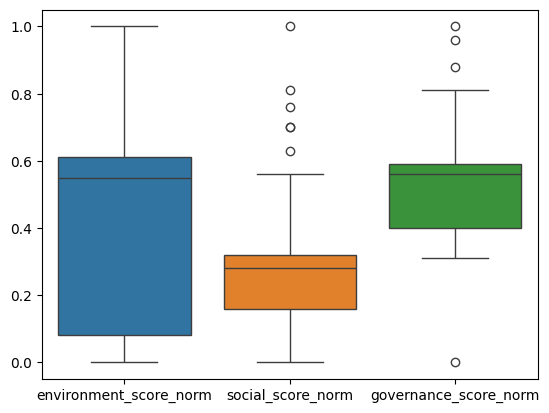

In [10]:
sns.boxplot(data=df[["environment_score_norm", "social_score_norm", "governance_score_norm"]])
plt.show()

## Pillar comparison: raw scores vs. normalised scores

Creating a new version of the boxplot we used to show the outliners in the original dataset again with the normalised version shows a clear differenece in the balance between the ESG pillars. 

The initial inspection of raw pillar score means (environment_score ≈405, social_score ≈292, governance_score ≈279) suggested a fairly smooth, proportional decline across the three pillars. Environment being the highest, followed by Social in the middle and Governance being the lowest. No one pillar stood out as dramatically different from the others.

Using the normalised scores changes the picture. The Environment (median ≈0.55) and Governance (median ≈0.56) pillars remain in very similar positions, but the Social (median ≈0.27) now sits meaningfully lower — roughly half the level of the other two pillars. This shows why normalisation was a necessary step before drawing conclusions: Governance was never genuinely behind Environment — it simply operated on a smaller numeric range. The real gap is between Social and the other two pillars.

### Reflection: is Social's lower performance surprising?

This result initially seemed counter-intuitive to me. I had assumed from my own experience interviewing stakeholders from businesses opertaing in the USA that social initiatives such as DEI and inclusive hiring policies are often faster and easier for companies to implement than environmental or governance reforms (which can require substantial structural or long-term investment). 

BUT...

The Social pillar in this rating likely covers far more than DEI alone. It potentially includes labour practices, supply chain human rights, product safety, and data privacy. It is also worth restating that this dataset does not disclose its rating methodology. It's possible the Social criteria are simply scored on a stricter basis than Environment or Governance, independent of actual company performance.
It could also be the case that social policies like wellbeing initiatives may be easier to announce than to substantiate under third-party scrutiny.

Without visibility into the rating agency's methodology, it isn't possible to say which explanation (or combination) is correct from this dataset alone.

## Comparing different industries 

In [7]:
df['industry'].unique()

array(['Media', 'Automobiles', 'Trading Companies and Distributors',
       'Consumer products', 'Hotels Restaurants and Leisure',
       'Diversified Consumer Services', 'Airlines', 'Insurance',
       'Communications', 'Building', 'Technology', 'Electrical Equipment',
       'Logistics and Transportation', 'Unknown', 'Biotechnology',
       'Health Care', 'Life Sciences Tools and Services', 'Banking',
       'Semiconductors', 'Pharmaceuticals', 'Financial Services',
       'Commercial Services and Supplies', 'Chemicals', 'Real Estate',
       'Utilities', 'Machinery', 'Food Products', 'Retail', 'Energy',
       'Road and Rail', 'Distributors', 'Beverages', 'Telecommunication',
       'Professional Services', 'Auto Components', 'Packaging',
       'Aerospace and Defense', 'Tobacco', 'Metals and Mining',
       'Construction', 'Textiles Apparel and Luxury Goods',
       'Industrial Conglomerates', 'Leisure Products', 'Marine'],
      dtype=object)

In [10]:
industry_counts = df['industry'].value_counts()
print(industry_counts)

industry
Technology                            63
Biotechnology                         56
Health Care                           51
Real Estate                           36
Financial Services                    33
Utilities                             30
Banking                               29
Electrical Equipment                  27
Insurance                             27
Retail                                26
Semiconductors                        24
Hotels Restaurants and Leisure        24
Media                                 23
Machinery                             21
Pharmaceuticals                       21
Energy                                21
Consumer products                     20
Chemicals                             19
Life Sciences Tools and Services      16
Food Products                         14
Unknown                               13
Aerospace and Defense                 11
Building                              10
Metals and Mining                     10
Textile

In [9]:
df.groupby("industry")[["environment_score_norm", "social_score_norm", "governance_score_norm"]].mean().round(2)

,environment_score_norm,social_score_norm,governance_score_norm
industry,,,
Aerospace and Defense,0.51,0.27,0.54
Airlines,0.24,0.21,0.43
Auto Components,0.27,0.17,0.43
Automobiles,0.37,0.14,0.40
Banking,0.27,0.26,0.47
Beverages,0.53,0.28,0.53
Biotechnology,0.21,0.22,0.54
Building,0.53,0.29,0.54
Chemicals,0.51,0.29,0.54


In [12]:
valid_industries = industry_counts[industry_counts >= 10].index

df_filtered = df[(df["industry"].isin(valid_industries)) & (df["industry"] != "Unknown")]

df_filtered["industry"].nunique()

23

In [14]:
industry_pillar_avg = df_filtered.groupby("industry")[["environment_score_norm", "social_score_norm", "governance_score_norm"]].mean()
industry_pillar_avg.round(2)

,environment_score_norm,social_score_norm,governance_score_norm
industry,,,
Aerospace and Defense,0.51,0.27,0.54
Banking,0.27,0.26,0.47
Biotechnology,0.21,0.22,0.54
Building,0.53,0.29,0.54
Chemicals,0.51,0.29,0.54
Consumer products,0.36,0.25,0.50
Electrical Equipment,0.35,0.22,0.51
Energy,0.61,0.29,0.55
Financial Services,0.32,0.23,0.48
